# **1.**

/tmp/ipython-input-2503094658.py:4: DtypeWarning: Columns (15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('turmas_limpo.csv')



--- Iniciando Análise Univariada ---

Analisando Variáveis Numéricas...

--- Capacidade do Aluno ---
count    43820.000000
mean        24.401963
std         28.321301
min          1.000000
25%          6.000000
50%         17.000000
75%         40.000000
max        503.000000
Name: capacidade_aluno, dtype: float64


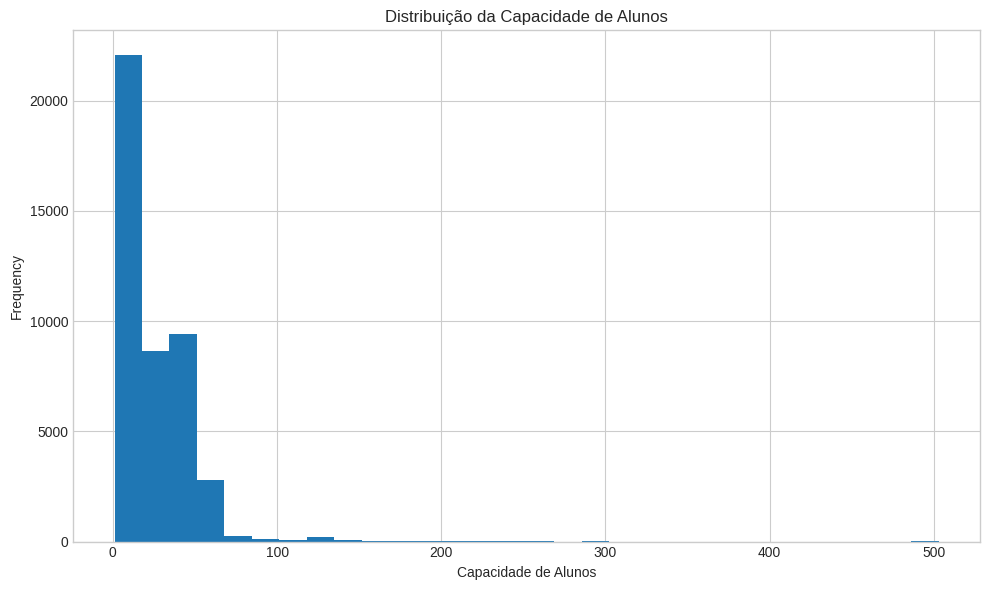


--- Total de Solicitações ---
count    43820.000000
mean        16.593245
std         21.344737
min          0.000000
25%          4.000000
50%          9.000000
75%         24.000000
max        658.000000
Name: total_solicitacoes, dtype: float64


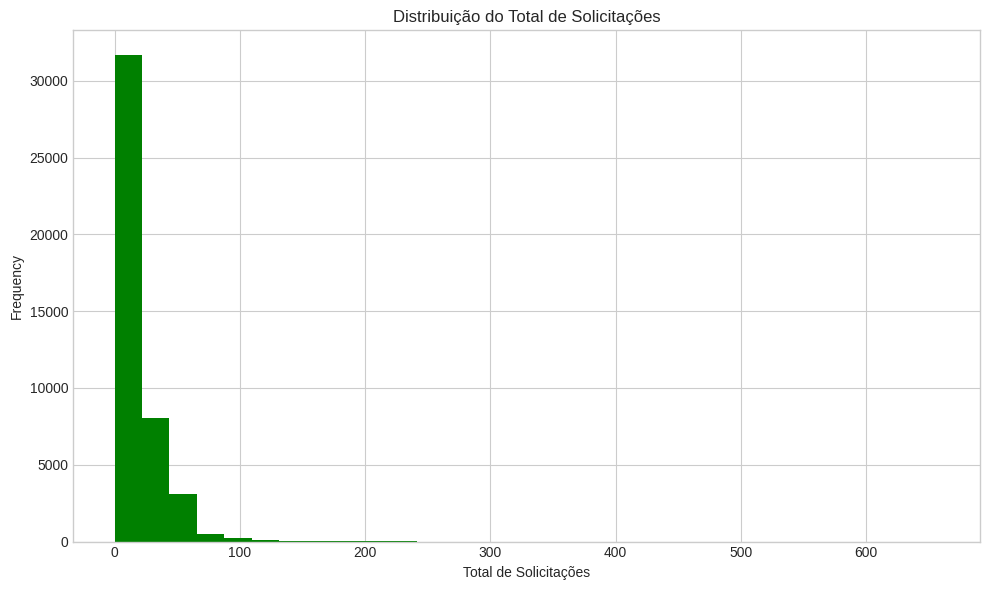


Analisando Variáveis Categóricas...

--- Nível de Ensino ---
nivel_ensino
graduação                35465
stricto sensu             5531
técnico                   1909
lato sensu                 631
formação complementar      285
Name: count, dtype: int64


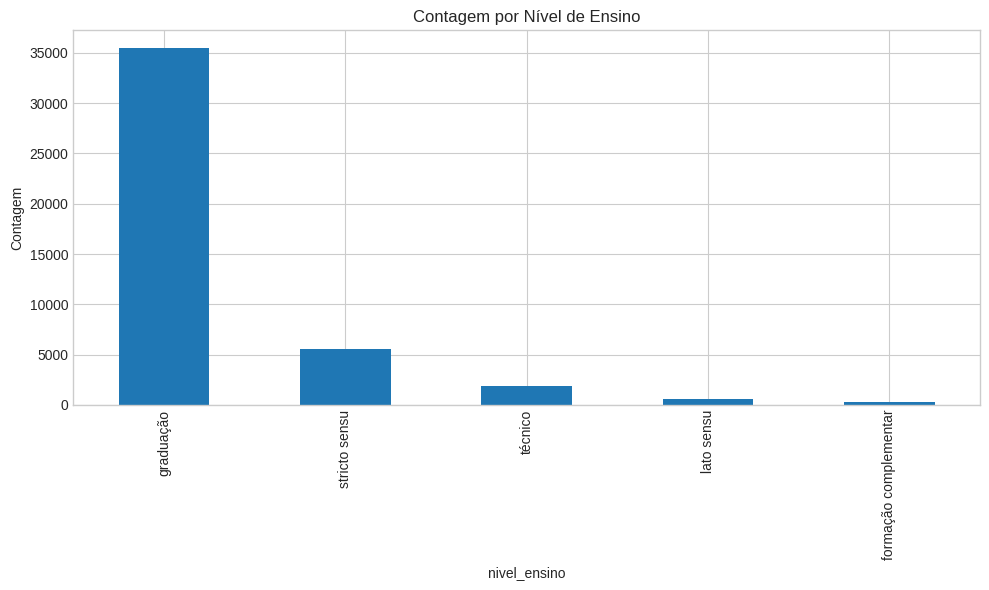


--- Campus da Turma ---
campus_turma
campus central          28609
não informado            8830
campus caicó             3330
campus santa cruz        2083
campus macaíba            497
campus currais novos      471
Name: count, dtype: int64


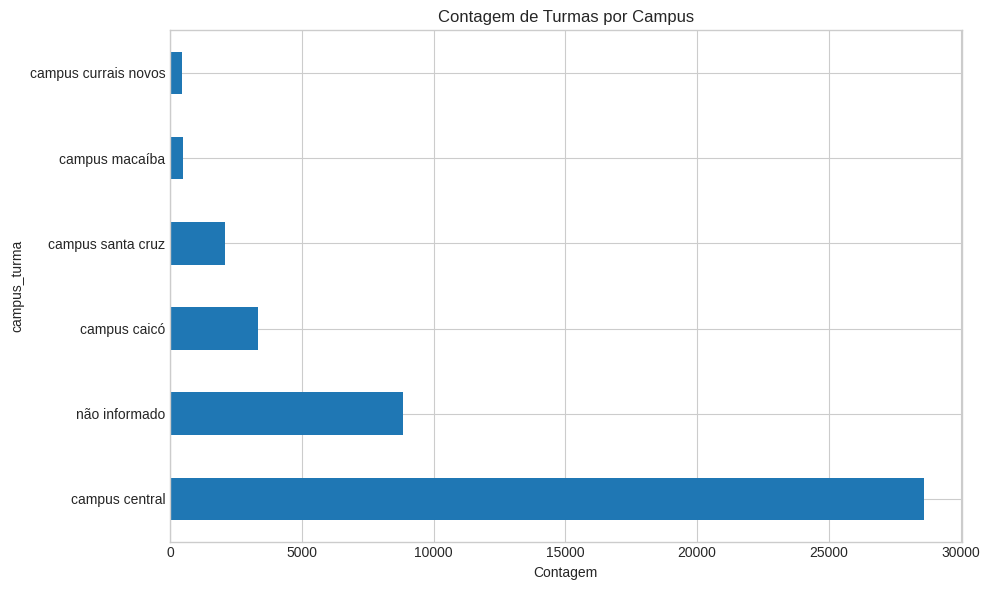


Analisando Variáveis Temporais...

--- Turmas por Ano ---
ano
2023.0    28074
2024.0    15746
Name: count, dtype: int64


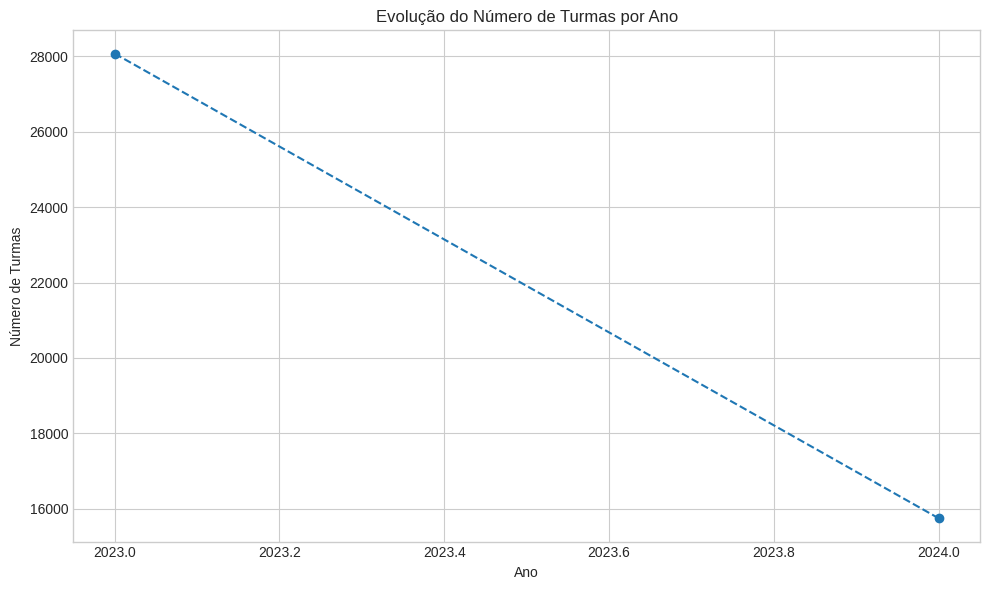


--- Análise Concluída ---


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('turmas_limpo.csv')
# --- 1. Análise Univariada ---
print("\n--- Iniciando Análise Univariada ---")

# Define um estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.autolayout'] = True


# --- 1.1 Variáveis Numéricas ---
print("\nAnalisando Variáveis Numéricas...")

# Para 'capacidade_aluno'
print("\n--- Capacidade do Aluno ---")
print(df['capacidade_aluno'].describe())
df['capacidade_aluno'].plot(kind='hist', bins=30, title='Distribuição da Capacidade de Alunos')
plt.xlabel('Capacidade de Alunos')
plt.show()

# Para 'total_solicitacoes'
print("\n--- Total de Solicitações ---")
print(df['total_solicitacoes'].describe())
df['total_solicitacoes'].plot(kind='hist', bins=30, title='Distribuição do Total de Solicitações', color='green')
plt.xlabel('Total de Solicitações')
plt.show()


# --- 1.2 Variáveis Categóricas ---
print("\nAnalisando Variáveis Categóricas...")

# Para 'nivel_ensino'
print("\n--- Nível de Ensino ---")
niveis = df['nivel_ensino'].value_counts()
print(niveis)
niveis.plot(kind='bar', title='Contagem por Nível de Ensino')
plt.ylabel('Contagem')
plt.show()

# Para 'campus_turma'
print("\n--- Campus da Turma ---")
campi = df['campus_turma'].value_counts()
print(campi)
campi.plot(kind='barh', title='Contagem de Turmas por Campus')
plt.xlabel('Contagem')
plt.show()


# --- 1.3 Variáveis Temporais ---
print("\nAnalisando Variáveis Temporais...")

# Análise de tendência de turmas por ano
print("\n--- Turmas por Ano ---")
turmas_por_ano = df['ano'].value_counts().sort_index()
print(turmas_por_ano)
turmas_por_ano.plot(kind='line', marker='o', linestyle='--', title='Evolução do Número de Turmas por Ano')
plt.ylabel('Número de Turmas')
plt.xlabel('Ano')
plt.grid(True)
plt.show()

print("\n--- Análise Concluída ---")

# **2.**


--- Iniciando Passo 2: Análise Bivariada ---

--- 2.1 Análise Numérica vs. Numérica ---
Matriz de Correlação:
                     capacidade_aluno  total_solicitacoes  ch_dedicada_periodo
capacidade_aluno             1.000000            0.522404             0.314563
total_solicitacoes           0.522404            1.000000             0.266779
ch_dedicada_periodo          0.314563            0.266779             1.000000


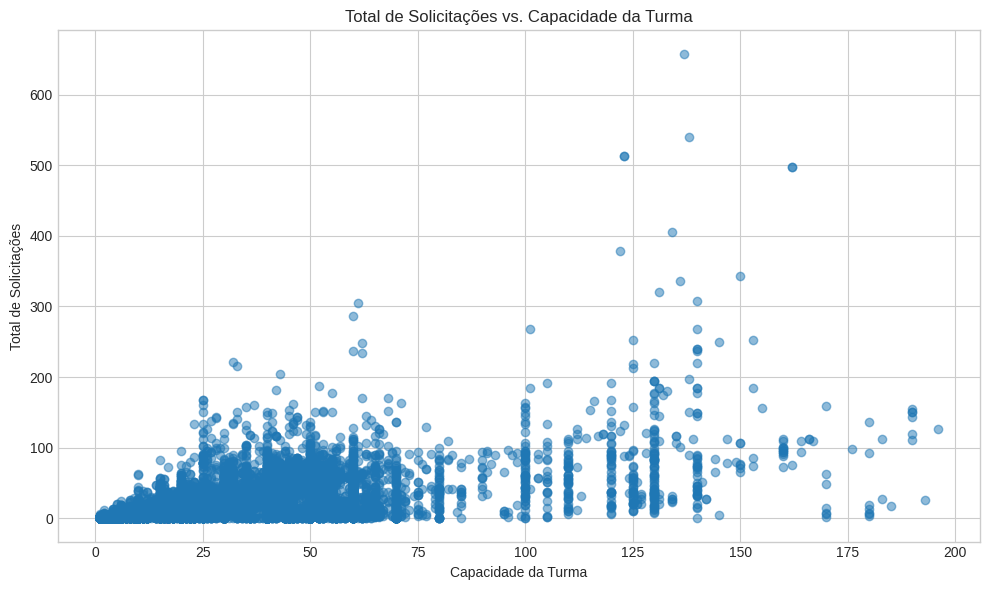


--- 2.2 Análise Categórica vs. Numérica ---


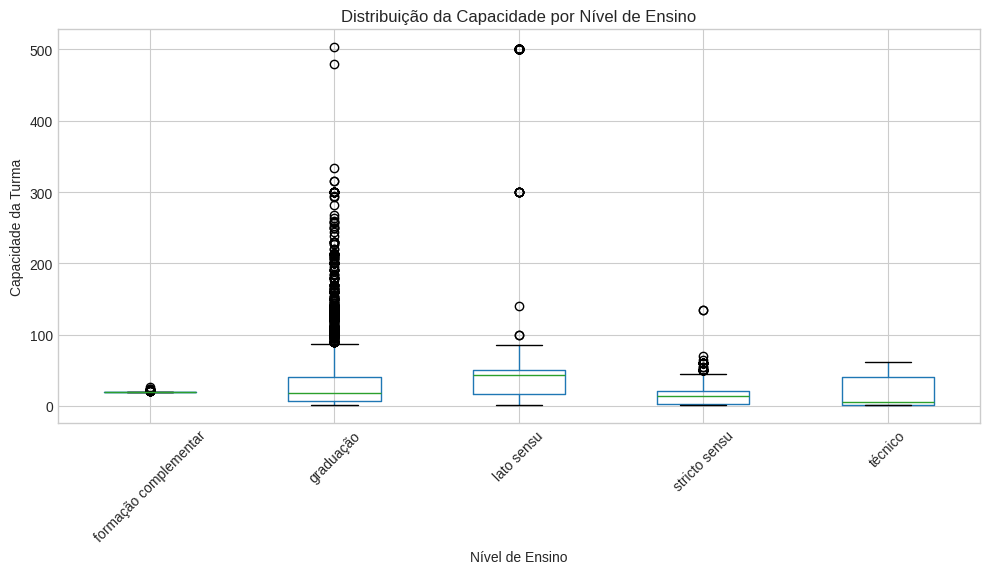

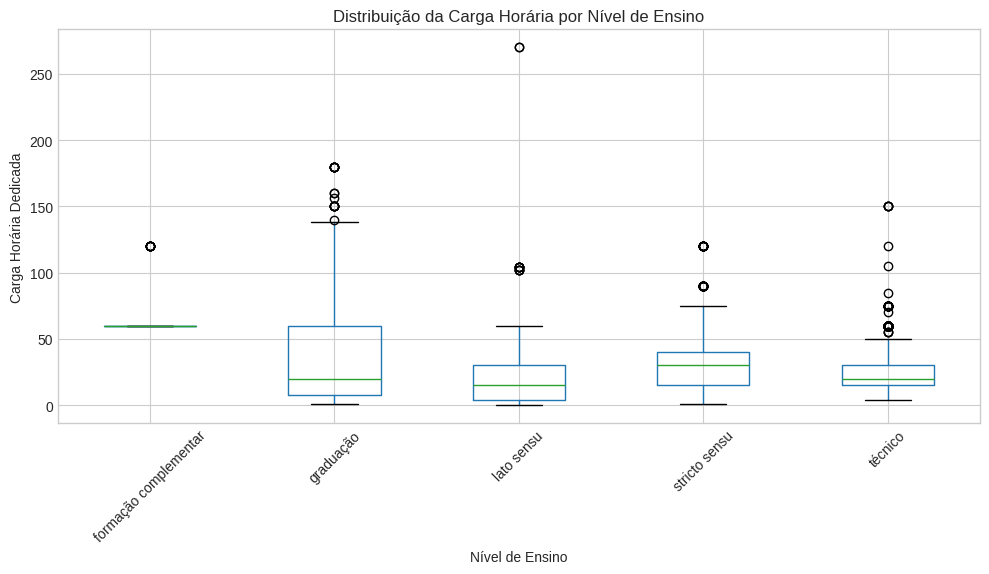


--- 2.3 Análise Categórica vs. Categórica ---
Tabela de Contingência: Nível de Ensino vs. Modalidade a Distância
distancia              False  True 
nivel_ensino                       
formação complementar    285      0
graduação              34972    492
lato sensu               540     91
stricto sensu           5497     34
técnico                 1909      0


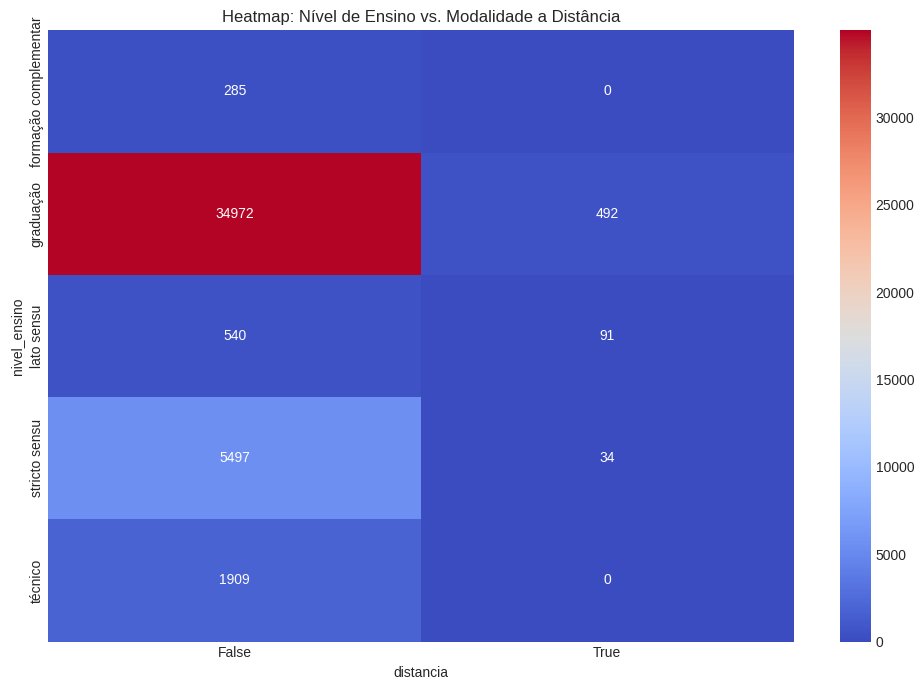


--- Análise Bivariada Concluída ---


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Vai usar no heatmap

# --- 2. Análise Bivariada ---
print("\n--- Iniciando Passo 2: Análise Bivariada ---")

# --- 2.1 Relação entre Variáveis Numéricas ---
print("\n--- 2.1 Análise Numérica vs. Numérica ---")

# Calculando a correlação entre as principais variáveis numéricas
numeric_cols = ['capacidade_aluno', 'total_solicitacoes', 'ch_dedicada_periodo']
correlacao = df[numeric_cols].corr()
print("Matriz de Correlação:")
print(correlacao)

# Gráfico de Dispersão (Scatter Plot): Total de Solicitações vs. Capacidade
# Filtra os dados para remover outliers e melhorar a visualização
df_filtrado = df[df['capacidade_aluno'] < 200]
plt.scatter(df_filtrado['capacidade_aluno'], df_filtrado['total_solicitacoes'], alpha=0.5)
plt.title('Total de Solicitações vs. Capacidade da Turma')
plt.xlabel('Capacidade da Turma')
plt.ylabel('Total de Solicitações')
plt.show()


# --- 2.2 Relação entre Variáveis Categóricas e Numéricas ---
print("\n--- 2.2 Análise Categórica vs. Numérica ---")

# Boxplot: Capacidade da Turma por Nível de Ensino
df.boxplot(column='capacidade_aluno', by='nivel_ensino')
plt.suptitle('') # Remove o título automático do pandas
plt.title('Distribuição da Capacidade por Nível de Ensino')
plt.ylabel('Capacidade da Turma')
plt.xlabel('Nível de Ensino')
plt.xticks(rotation=45)
plt.show()

# Boxplot: Carga Horária por Nível de Ensino
df.boxplot(column='ch_dedicada_periodo', by='nivel_ensino')
plt.suptitle('')
plt.title('Distribuição da Carga Horária por Nível de Ensino')
plt.ylabel('Carga Horária Dedicada')
plt.xlabel('Nível de Ensino')
plt.xticks(rotation=45)
plt.show()


# --- 2.3 Relação entre Variáveis Categóricas ---
print("\n--- 2.3 Análise Categórica vs. Categórica ---")

# Tabela de Contingência: Modalidade (Distancia) vs. Nível de Ensino
tabela_contingencia = pd.crosstab(df['nivel_ensino'], df['distancia'])
print("Tabela de Contingência: Nível de Ensino vs. Modalidade a Distância")
print(tabela_contingencia)

# Heatmap da Tabela de Contingência
plt.figure(figsize=(10, 7)) # Ajustando o tamanho da figura para o heatmap
sns.heatmap(tabela_contingencia, annot=True, fmt="d", cmap="coolwarm")
plt.title('Heatmap: Nível de Ensino vs. Modalidade a Distância')
plt.show()

print("\n--- Análise Bivariada Concluída ---")

# **3.**


--- Iniciando Questão 3: Análise Temporal ---

--- 3.1 Analisando Tendências Anuais ---


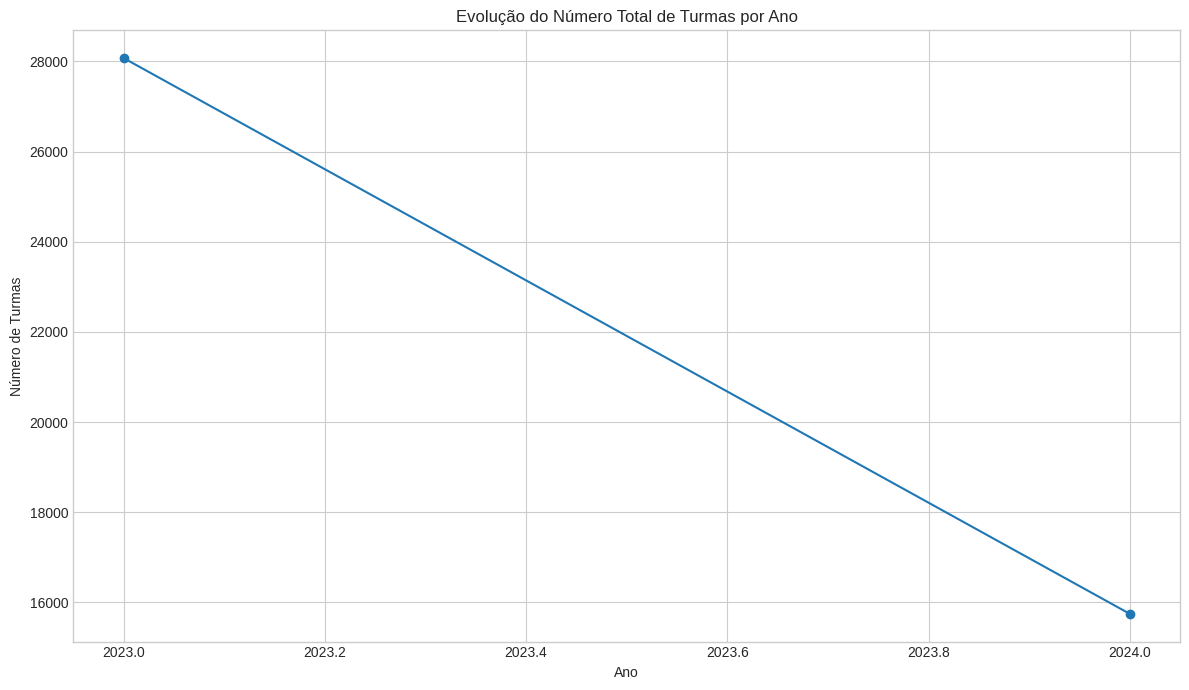

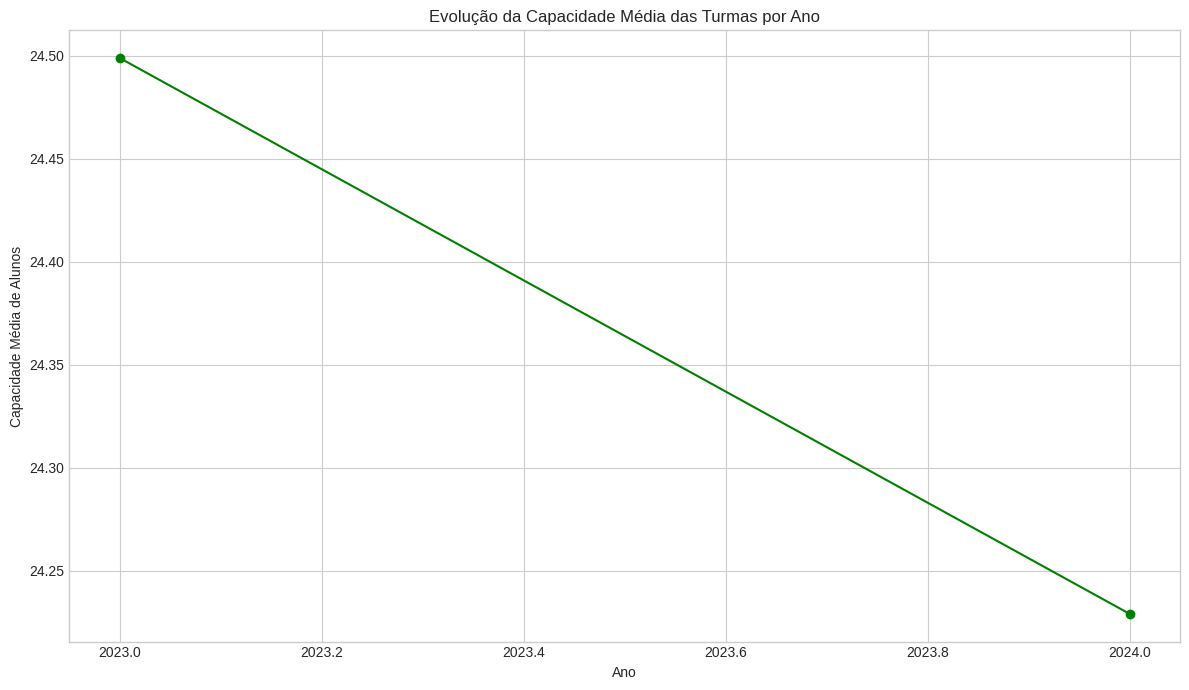

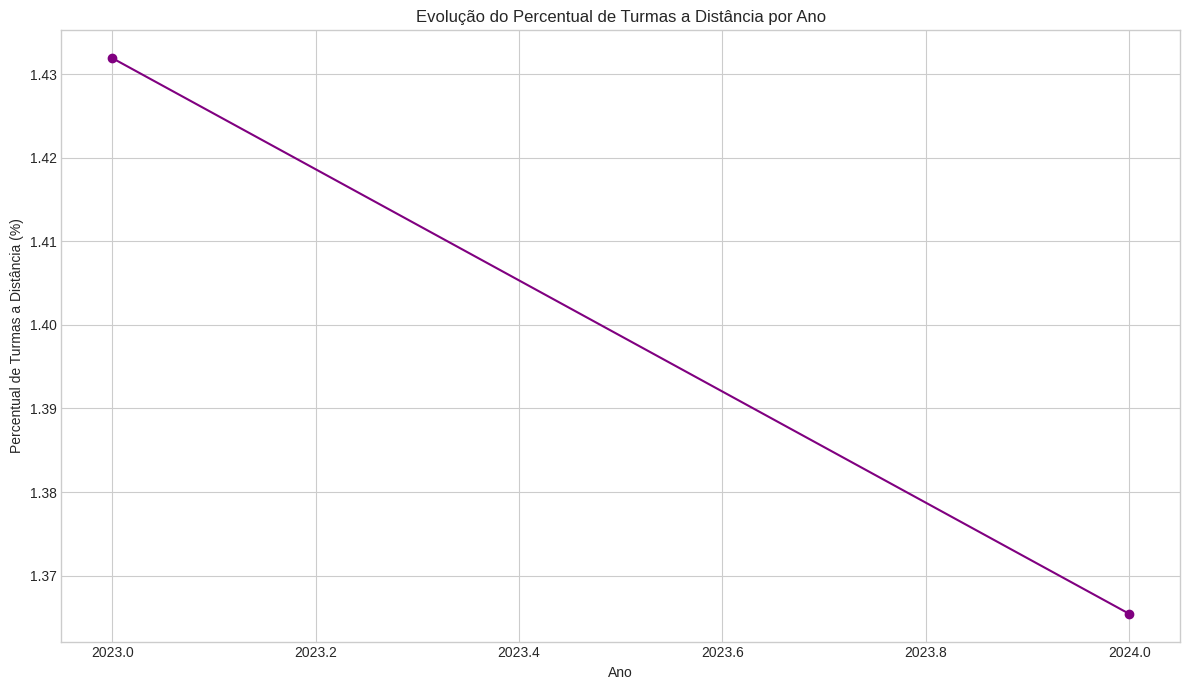


Distribuição de turmas por nível de ensino ao longo dos anos:
nivel_ensino  formação complementar  graduação  lato sensu  stricto sensu  \
ano                                                                         
2023.0                          150      23078         415           3349   
2024.0                          135      12386         216           2182   

nivel_ensino  técnico  
ano                    
2023.0           1082  
2024.0            827  


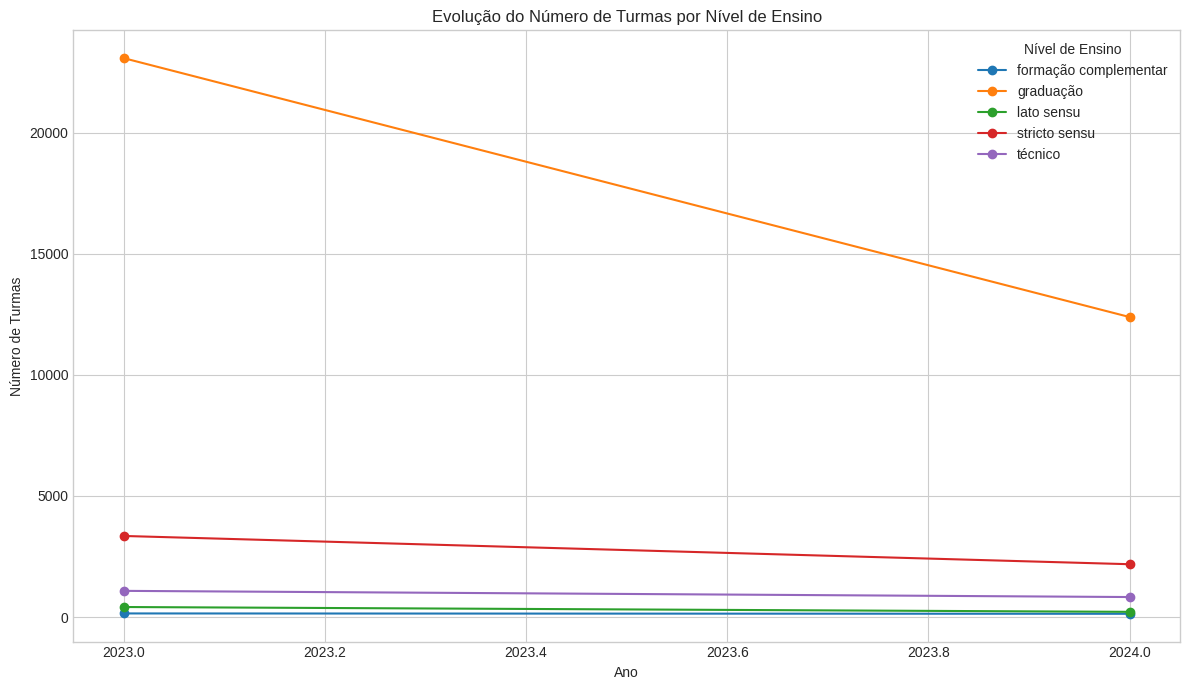


--- 3.2 Analisando Padrões Sazonais entre Períodos ---

Contagem de turmas por período a cada ano:
periodo    1.0    2.0
ano                  
2023.0   14103  13971
2024.0   14247   1499


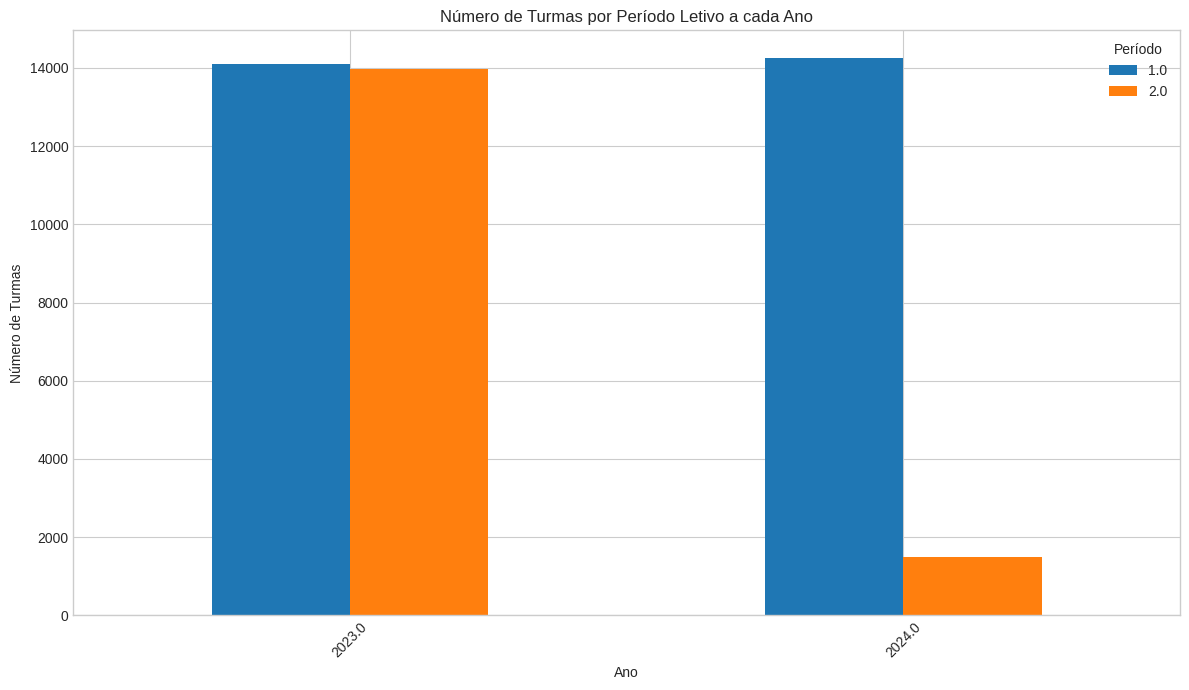


--- Análise Temporal Concluída ---


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 3. Análise Temporal ---
print("\n--- Iniciando Questão 3: Análise Temporal ---")

# Define um estilo e tamanho padrão para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.autolayout'] = True


# --- 3.1 Tendências Anuais ---
print("\n--- 3.1 Analisando Tendências Anuais ---")

# Tendência do número total de turmas por ano
turmas_por_ano = df['ano'].value_counts().sort_index()
turmas_por_ano.plot(kind='line', marker='o', linestyle='-')
plt.title('Evolução do Número Total de Turmas por Ano')
plt.ylabel('Número de Turmas')
plt.xlabel('Ano')
plt.grid(True)
plt.show()

# Tendência da capacidade média das turmas por ano
capacidade_media_ano = df.groupby('ano')['capacidade_aluno'].mean()
capacidade_media_ano.plot(kind='line', marker='o', linestyle='-', color='green')
plt.title('Evolução da Capacidade Média das Turmas por Ano')
plt.ylabel('Capacidade Média de Alunos')
plt.xlabel('Ano')
plt.grid(True)
plt.show()

# Tendência do crescimento da modalidade à distância
# Primeiro, calcula o total de turmas por ano
total_turmas_ano = df.groupby('ano')['distancia'].count()
# Depois, calcula o total de turmas a distância por ano
turmas_distancia_ano = df[df['distancia'] == True].groupby('ano')['distancia'].count()
# Calcula o percentual
percentual_distancia_ano = (turmas_distancia_ano / total_turmas_ano) * 100
percentual_distancia_ano.plot(kind='line', marker='o', linestyle='-', color='purple')
plt.title('Evolução do Percentual de Turmas a Distância por Ano')
plt.ylabel('Percentual de Turmas a Distância (%)')
plt.xlabel('Ano')
plt.grid(True)
plt.show()

# Tendência da distribuição por nível de ensino ao longo dos anos
distribuicao_nivel_ano = df.groupby(['ano', 'nivel_ensino']).size().unstack(fill_value=0)
print("\nDistribuição de turmas por nível de ensino ao longo dos anos:")
print(distribuicao_nivel_ano)
distribuicao_nivel_ano.plot(kind='line', marker='o', linestyle='-')
plt.title('Evolução do Número de Turmas por Nível de Ensino')
plt.ylabel('Número de Turmas')
plt.xlabel('Ano')
plt.legend(title='Nível de Ensino')
plt.grid(True)
plt.show()


# --- 3.2 Padrões Sazonais (entre períodos) ---
print("\n--- 3.2 Analisando Padrões Sazonais entre Períodos ---")

# Contagem de turmas por período para cada ano
turmas_por_periodo = df.groupby(['ano', 'periodo']).size().unstack(fill_value=0)
print("\nContagem de turmas por período a cada ano:")
print(turmas_por_periodo)

# Gráfico de barras para comparar os períodos
turmas_por_periodo.plot(kind='bar', stacked=False)
plt.title('Número de Turmas por Período Letivo a cada Ano')
plt.ylabel('Número de Turmas')
plt.xlabel('Ano')
plt.xticks(rotation=45)
plt.legend(title='Período')
plt.grid(True)
plt.show()


print("\n--- Análise Temporal Concluída ---")

# **4.** DESCONSIDERAR

# **5.**

É possível obter inúmeras conclusões baseado nos gráficos elaborados. Como:

**Interesse vs. Capacidade**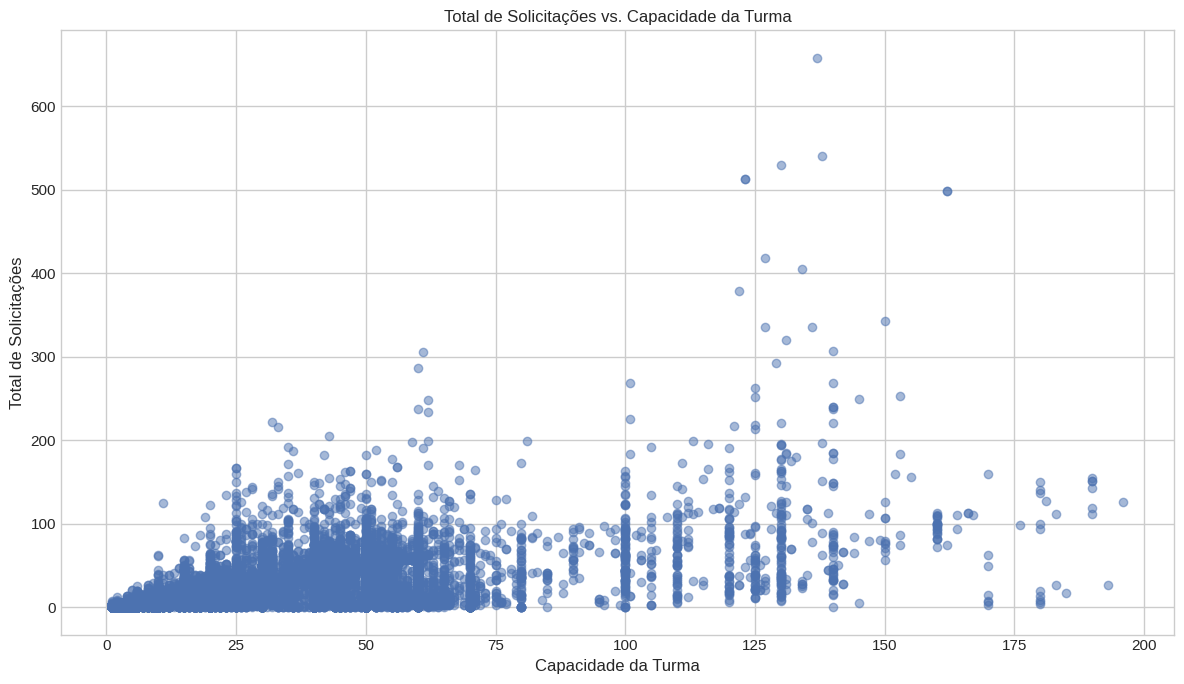

Pode-se perceber que há muitas turmas que tem pouca capacidade e muita procura. Enquanto existem turmas com muita capacidade e pouca procura. A faculdade pode rever a alocação de vagas e deixá-la mais otimizada, evitando o gasto desnecessário de recursos.

**Campus Cental é desproporcionalmente o maior**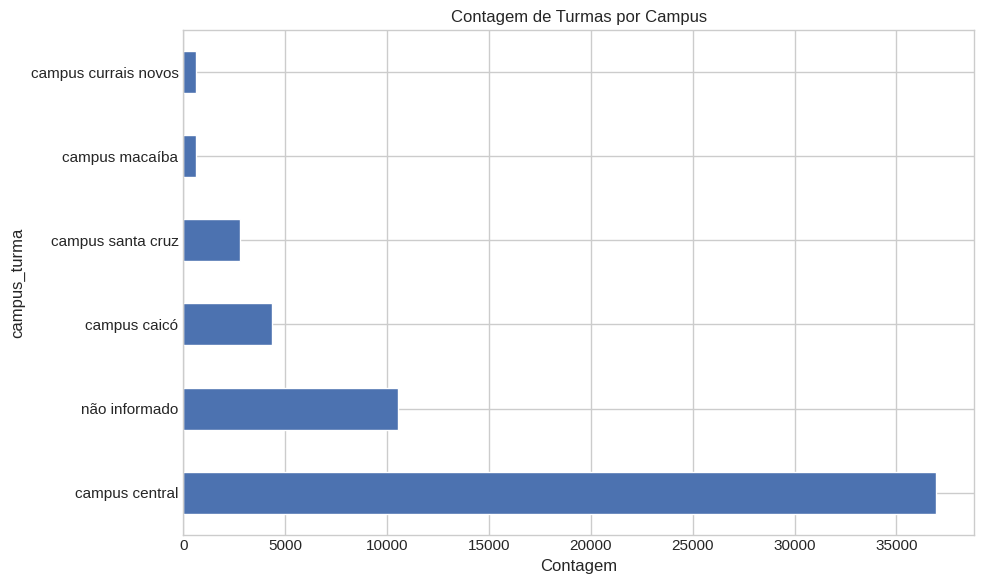

Essa enorme diferença, pode ser um ponto de atenção para o desenvolvimento dos campus fora de Natal, garantindo que eles também tenham uam diversidade e volume de oferta que atendam às suas comunidades locais

**Número de Turmas vs. Capacidade das Turmas**

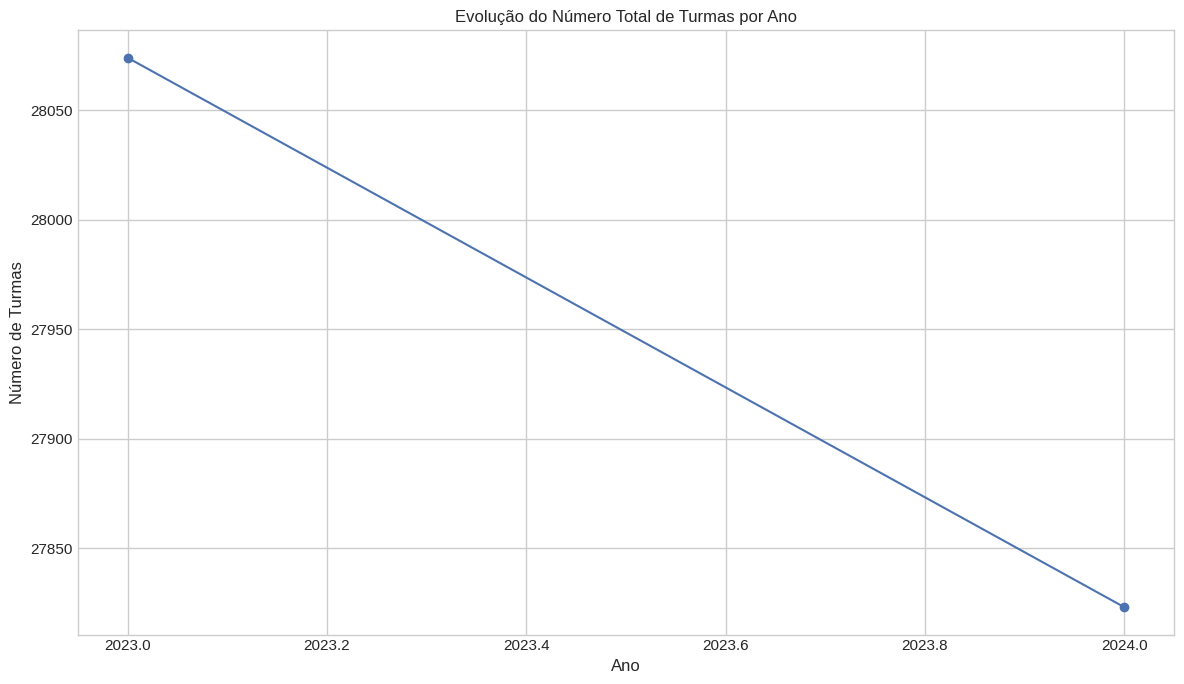

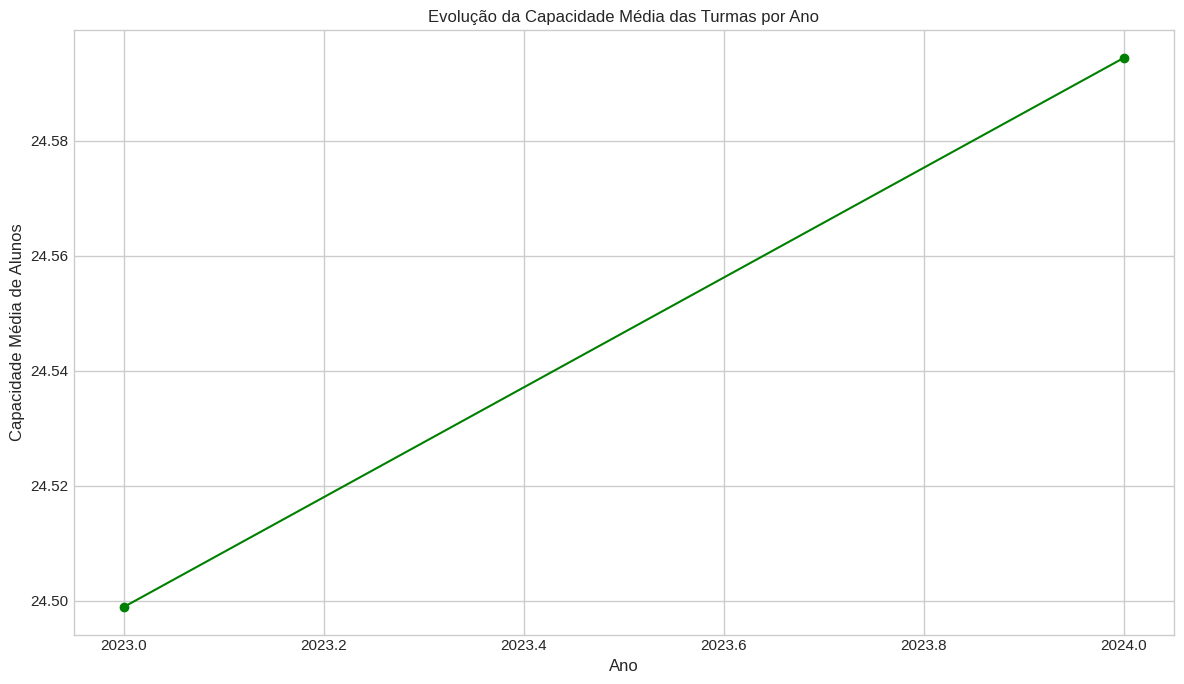

Pode-se observar que a quantidade de turmas diminuiu, porém a quantidade média de alunos por turma aumentou. Indicando que as turmas se tornaram mais densas de 2023 para 2024